# 2026 Payin Projection Inference V1

Thin inference notebook for scoring unseen active/recent loans from a persisted V5 model run.

Core behavior:

- Day-0 loans are valid: Stage A uses origination features, Stage B sees zero prior payment history, and Stage C uses fallback recovery by default class.
- Daily snapshots are valid: set `AS_OF_DATE`, then actual paid-to-date dollars and observed installment outcomes update the projection.
- No retraining happens here.

In [1]:
# Configuration
from pathlib import Path
import sys

import pandas as pd

# Resolve project root whether the notebook is launched from repo root or notebook folder.
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'util').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Set RUN_TAG to a specific folder name like "20260429T202128Z".
# Leave as None to load the newest persisted run.
RUN_TAG = None
AS_OF_DATE = pd.Timestamp.today().normalize()
N_SIMS = 500

# Match the V5 training exclusion window: training used ApplicationDate < AS_OF_DATE - 120 days.
# Inference defaults to the complementary recent cohort: ApplicationDate >= AS_OF_DATE - 120 days.
INFERENCE_LOOKBACK_DAYS = 120
COHORT_APPLICATION_START = AS_OF_DATE - pd.Timedelta(days=INFERENCE_LOOKBACK_DAYS)
COHORT_APPLICATION_END = AS_OF_DATE

env_path = project_root / '.env'
sql_path = project_root / 'sql_scripts' / 'jcx_raw_inference_v1.sql'
payment_sql_path = project_root / 'sql_scripts' / 'SP_payment_data_inference_v1.sql'

print('project_root:', project_root)
print('AS_OF_DATE:', AS_OF_DATE.date())
print('raw inference SQL:', sql_path.name)
print('payment inference SQL:', payment_sql_path.name)
print('inference ApplicationDate window:', COHORT_APPLICATION_START.date(), 'through', COHORT_APPLICATION_END.date())

project_root: /Users/starsrain/2025_concord/yieldCurve_augmenting
AS_OF_DATE: 2026-05-11
raw inference SQL: jcx_raw_inference_v1.sql
payment inference SQL: SP_payment_data_inference_v1.sql
inference ApplicationDate window: 2026-01-11 through 2026-05-11


In [2]:
# Load persisted model run.
from pathlib import Path
import sys

# Keep this cell rerunnable even after a kernel restart.
if 'project_root' not in globals():
    cwd = Path.cwd().resolve()
    project_root = cwd if (cwd / 'util').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from util.projection_model_persistence import load_projection_run

runs_root = project_root / 'prediction_models' / 'runs'
if RUN_TAG is None:
    run_dirs = sorted([p for p in runs_root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f'No persisted runs found under {runs_root}')
    RUN_TAG = run_dirs[-1].name

model_run = load_projection_run(project_root, RUN_TAG)
if not model_run.feature_contract.get('category_maps'):
    print('WARNING: this run has no persisted category_maps. Rerun the final V5 persistence cell for production inference.')

print('loaded run:', model_run.run_dir)
print('model version:', model_run.metadata.get('model_version'))
print('class order:', model_run.feature_contract.get('class_order'))

loaded run: /Users/starsrain/2025_concord/yieldCurve_augmenting/prediction_models/runs/20260429T212208Z
model version: projection_v5
class order: ['FPD', 'SPD', 'TPD', 'LatePD', 'Clean']


In [3]:
# Load active/recent loan data and payment attempts.
from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_result_sets, execute_sql_and_read_temp_table

engine = create_db_engine(env_path)
raw_df = execute_sql_and_read_temp_table(engine, read_sql_file(sql_path), '#t17_combined')
payment_sets = execute_sql_and_read_result_sets(engine, read_sql_file(payment_sql_path), max_sets=3)
payment_normal_df = payment_sets[0] if len(payment_sets) > 0 else pd.DataFrame()
payment_arr_df = payment_sets[1] if len(payment_sets) > 1 else pd.DataFrame()
payment_3p_df = payment_sets[2] if len(payment_sets) > 2 else pd.DataFrame()

raw_df['OriginationDate'] = pd.to_datetime(raw_df['OriginationDate'], errors='coerce')
raw_df['ApplicationDate'] = (
    pd.to_datetime(raw_df['AppYear'].astype('Int64').astype(str) + '-01-01', errors='coerce')
    + pd.to_timedelta((pd.to_numeric(raw_df['AppWeek'], errors='coerce').fillna(1) - 1) * 7, unit='D')
)
raw_df['ApplicationDate'] = raw_df['ApplicationDate'].fillna(raw_df['OriginationDate'])

raw_before_filter = raw_df.copy()
raw_df = raw_df[
    (raw_df['ApplicationDate'] >= pd.to_datetime(COHORT_APPLICATION_START))
    & (raw_df['ApplicationDate'] <= pd.to_datetime(COHORT_APPLICATION_END))
].copy()

loan_ids = set(raw_df['LoanID'].dropna())
for name, frame in [('normal', payment_normal_df), ('arr', payment_arr_df), ('third_party', payment_3p_df)]:
    if 'LoanID' in frame.columns:
        keep = frame['LoanID'].isin(loan_ids)
        if name == 'normal':
            payment_normal_df = frame[keep].copy()
        elif name == 'arr':
            payment_arr_df = frame[keep].copy()
        else:
            payment_3p_df = frame[keep].copy()

print('raw inference SQL:', sql_path.name)
print('payment inference SQL:', payment_sql_path.name)
print('raw_df loans before notebook as-of guard:', raw_before_filter['LoanID'].nunique())
print('inference ApplicationDate window:', pd.to_datetime(COHORT_APPLICATION_START).date(), 'through', pd.to_datetime(COHORT_APPLICATION_END).date())
print('raw_df shape:', raw_df.shape)
print('raw_df loans:', raw_df['LoanID'].nunique())
print('ApplicationDate range:', raw_df['ApplicationDate'].min(), 'to', raw_df['ApplicationDate'].max())
print('payment_normal_df shape:', payment_normal_df.shape)
print('payment_arr_df shape:', payment_arr_df.shape)
print('payment_3p_df shape:', payment_3p_df.shape)

raw inference SQL: jcx_raw_inference_v1.sql
payment inference SQL: SP_payment_data_inference_v1.sql
raw_df loans before notebook as-of guard: 16615
inference ApplicationDate window: 2026-01-06 through 2026-05-06
raw_df shape: (139059, 34)
raw_df loans: 16194
ApplicationDate range: 2026-01-08 00:00:00 to 2026-04-30 00:00:00
payment_normal_df shape: (61585, 17)
payment_arr_df shape: (947, 18)
payment_3p_df shape: (2, 18)


In [4]:
# Score the cohort as of AS_OF_DATE.
import importlib

import util.projection_feature_builder as _pfb
import util.projection_inference as _pinf
import util.projection_model_persistence as _pmp
import util.projection_payment_features as _ppay
import util.projection_simulator as _psim

importlib.reload(_ppay)
importlib.reload(_psim)
importlib.reload(_pfb)
importlib.reload(_pinf)
importlib.reload(_pmp)


from util.projection_inference import score_live_projection

results = score_live_projection(
    model_run=model_run,
    raw_df=raw_df,
    payment_normal_df=payment_normal_df,
    payment_arr_df=payment_arr_df,
    payment_3p_df=payment_3p_df,
    as_of_date=AS_OF_DATE,
    n_sims=N_SIMS,
)

portfolio_ci = results['portfolio_ci']
print(f"portfolio projected final payin: mean={portfolio_ci['mean']:.3f}, 90% CI=[{portfolio_ci['lo05']:.3f}, {portfolio_ci['hi95']:.3f}]")
print(f"CI width: {portfolio_ci['hi95'] - portfolio_ci['lo05']:.3f}")

portfolio projected final payin: mean=1.681, 90% CI=[1.666, 1.698]
CI width: 0.032


In [5]:
# Sanity checks: where is the live projection coming from?
# This cell uses existing `results` objects only; it does not reload SQL or rerun training.
import numpy as np
import pandas as pd

from util.projection_labels import PAYOFF_TYPE_COLLAPSED_ORDER
from util.projection_stage_b import predict_expected_amount

classes = list(PAYOFF_TYPE_COLLAPSED_ORDER)
prob_cols = [f'P_{c}' for c in classes]

loan_features = results['loan_features'].copy()
seq_features = results['seq_features'].copy()
posterior_probs = results['posterior_probs'].copy()
payin_pre_recovery = results['payin_matrix_pre_recovery'].copy()
payin_final = results['payin_matrix'].copy()
recovery_add = payin_final - payin_pre_recovery

loan_idx = loan_features.set_index('LoanID').copy()
loan_idx['OriginatedAmount'] = pd.to_numeric(loan_idx['OriginatedAmount'], errors='coerce').fillna(0.0)
loan_idx['TotalRealizedPayment'] = pd.to_numeric(loan_idx['TotalRealizedPayment'], errors='coerce').fillna(0.0)
loan_idx['realized_payin_to_date'] = (
    loan_idx['TotalRealizedPayment'] / loan_idx['OriginatedAmount'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0.0)
loan_idx['origination_month'] = pd.to_datetime(
    loan_idx['OriginationDate'], errors='coerce'
).dt.to_period('M').astype(str)

# Align all matrices to loan order.
common_loans = payin_final.index.intersection(loan_idx.index)
payin_pre_recovery = payin_pre_recovery.reindex(common_loans)
payin_final = payin_final.reindex(common_loans)
recovery_add = recovery_add.reindex(common_loans)
posterior_probs = posterior_probs.reindex(common_loans)
loan_idx = loan_idx.reindex(common_loans)

P = posterior_probs[prob_cols].to_numpy(dtype=float)
P = P / np.clip(P.sum(axis=1, keepdims=True), 1e-12, None)
M_pre = payin_pre_recovery[classes].to_numpy(dtype=float)
M_final = payin_final[classes].to_numpy(dtype=float)
M_recovery = recovery_add[classes].to_numpy(dtype=float)

loan_decomp = pd.DataFrame(index=common_loans)
loan_decomp['OriginatedAmount'] = loan_idx['OriginatedAmount']
loan_decomp['origination_month'] = loan_idx['origination_month']
loan_decomp['realized_payin_to_date'] = loan_idx['realized_payin_to_date']
loan_decomp['expected_pre_recovery_payin'] = (P * M_pre).sum(axis=1)
loan_decomp['expected_recovery_add'] = (P * M_recovery).sum(axis=1)
loan_decomp['expected_final_payin'] = (P * M_final).sum(axis=1)
loan_decomp['implied_future_normal_payin'] = (
    loan_decomp['expected_pre_recovery_payin'] - loan_decomp['realized_payin_to_date']
)
loan_decomp['final_minus_realized'] = (
    loan_decomp['expected_final_payin'] - loan_decomp['realized_payin_to_date']
)

if len(seq_features):
    row_counts = (
        seq_features.assign(is_observed=seq_features.get('is_observed', False).astype(bool))
        .groupby('LoanID')
        .agg(
            total_installment_rows=('InstallmentNumber', 'size'),
            observed_installment_rows=('is_observed', 'sum'),
        )
    )
    row_counts['future_installment_rows'] = (
        row_counts['total_installment_rows'] - row_counts['observed_installment_rows']
    )
else:
    row_counts = pd.DataFrame(
        0,
        index=common_loans,
        columns=['total_installment_rows', 'observed_installment_rows', 'future_installment_rows'],
    )
loan_decomp = loan_decomp.join(row_counts, how='left').fillna({
    'total_installment_rows': 0,
    'observed_installment_rows': 0,
    'future_installment_rows': 0,
})


def _weighted_ratio(df, col):
    denom = df['OriginatedAmount'].sum()
    return (df[col].mul(df['OriginatedAmount']).sum() / denom) if denom else np.nan

cohort_decomp = (
    loan_decomp.groupby('origination_month', dropna=False)
    .apply(lambda df: pd.Series({
        'loans': df.index.nunique(),
        'originated_amount': df['OriginatedAmount'].sum(),
        'realized_payin_to_date': _weighted_ratio(df, 'realized_payin_to_date'),
        'expected_pre_recovery_payin': _weighted_ratio(df, 'expected_pre_recovery_payin'),
        'implied_future_normal_payin': _weighted_ratio(df, 'implied_future_normal_payin'),
        'expected_recovery_add': _weighted_ratio(df, 'expected_recovery_add'),
        'expected_final_payin': _weighted_ratio(df, 'expected_final_payin'),
        'final_minus_realized': _weighted_ratio(df, 'final_minus_realized'),
        'avg_total_installment_rows': df['total_installment_rows'].mean(),
        'avg_observed_installment_rows': df['observed_installment_rows'].mean(),
        'avg_future_installment_rows': df['future_installment_rows'].mean(),
    }))
    .reset_index()
)

print('1) Cohort decomposition: realized + implied future normal + recovery')
display(cohort_decomp.round(3))

# Class-conditional payoff paths by cohort month. These are the values Stage A weights together.
class_matrix = payin_final[classes].join(loan_idx[['origination_month', 'OriginatedAmount']])
class_payoff_by_month = (
    class_matrix.groupby('origination_month', dropna=False)
    .apply(lambda df: pd.Series({
        cls: (df[cls].mul(df['OriginatedAmount']).sum() / df['OriginatedAmount'].sum())
        if df['OriginatedAmount'].sum() else np.nan
        for cls in classes
    }))
    .reset_index()
)

posterior_mix = posterior_probs[prob_cols].join(loan_idx[['origination_month', 'OriginatedAmount']])
posterior_mix_by_month = (
    posterior_mix.groupby('origination_month', dropna=False)
    .apply(lambda df: pd.Series({
        col: (df[col].mul(df['OriginatedAmount']).sum() / df['OriginatedAmount'].sum())
        if df['OriginatedAmount'].sum() else np.nan
        for col in prob_cols
    }))
    .reset_index()
)

print('2) Class-conditional final payin matrix means by month')
display(class_payoff_by_month.round(3))
print('3) Posterior Stage A class mix by month')
display(posterior_mix_by_month.round(3))

# Check whether any class path is below realized-to-date. This should be rare or explainable;
# if large, live inference is not properly anchoring already-collected dollars.
realized = loan_idx['realized_payin_to_date']
floor_violations = payin_final[classes].lt(realized, axis=0)
floor_violation_summary = pd.DataFrame({
    'class': classes,
    'share_loans_final_path_below_realized': [floor_violations[c].mean() for c in classes],
    'avg_shortfall_when_violated': [
        (realized[floor_violations[c]] - payin_final.loc[floor_violations[c], c]).mean()
        if floor_violations[c].any() else 0.0
        for c in classes
    ],
})
print('4) Floor check: class paths below already-realized payin')
display(floor_violation_summary.round(4))

# Stage B future-row sanity: compare conditional amount vs unconditional expected amount.
if len(seq_features):
    stage_b_preds = predict_expected_amount(model_run.stage_b, seq_features)
    b = seq_features[['LoanID', 'InstallmentNumber']].copy()
    b['is_observed'] = seq_features.get('is_observed', False).astype(bool).values
    b['p_collected'] = stage_b_preds['p_collected'].values
    b['e_amount_if_collected'] = stage_b_preds['e_amount_if_collected'].values
    b['e_amount_unconditional'] = stage_b_preds['e_amount'].values
    b = b.merge(
        loan_idx[['origination_month', 'OriginatedAmount']],
        left_on='LoanID', right_index=True, how='left'
    )
    future_b = b[~b['is_observed']].copy()
    if len(future_b):
        future_loan = (
            future_b.groupby('LoanID')
            .agg(
                origination_month=('origination_month', 'first'),
                OriginatedAmount=('OriginatedAmount', 'first'),
                future_rows=('InstallmentNumber', 'size'),
                avg_p_collected=('p_collected', 'mean'),
                future_conditional_amount=('e_amount_if_collected', 'sum'),
                future_unconditional_amount=('e_amount_unconditional', 'sum'),
            )
        )
        future_stage_b_summary = (
            future_loan.groupby('origination_month', dropna=False)
            .apply(lambda df: pd.Series({
                'loans_with_future_rows': df.index.nunique(),
                'avg_future_rows': df['future_rows'].mean(),
                'avg_p_collected': df['avg_p_collected'].mean(),
                'future_conditional_payin': df['future_conditional_amount'].sum() / df['OriginatedAmount'].sum(),
                'future_unconditional_payin': df['future_unconditional_amount'].sum() / df['OriginatedAmount'].sum(),
                'conditional_minus_unconditional': (
                    df['future_conditional_amount'].sum() - df['future_unconditional_amount'].sum()
                ) / df['OriginatedAmount'].sum(),
            }))
            .reset_index()
        )
        print('5) Stage B future-row sanity: conditional vs unconditional remaining normal payments')
        display(future_stage_b_summary.round(3))
    else:
        print('5) Stage B future-row sanity: no future rows in this snapshot.')
else:
    print('5) Stage B future-row sanity: seq_features is empty.')

1) Cohort decomposition: realized + implied future normal + recovery


/var/folders/b7/d1qg7gm9009f_cps7l193hch0000gn/T/ipykernel_63693/361390640.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,origination_month,loans,originated_amount,realized_payin_to_date,expected_pre_recovery_payin,implied_future_normal_payin,expected_recovery_add,expected_final_payin,final_minus_realized,avg_total_installment_rows,avg_observed_installment_rows,avg_future_installment_rows
0,2026-01,3535.0,2681300.0,1.276,1.351,0.075,0.022,1.373,0.097,5.745,3.644,2.101
1,2026-02,3634.0,2798850.0,1.084,1.390,0.306,0.016,1.406,0.322,6.091,2.968,3.123
2,2026-03,4217.0,3354000.0,0.803,1.575,0.772,0.010,1.585,0.783,8.078,2.254,5.824
3,2026-04,4423.0,3463350.0,0.351,2.098,1.747,0.013,2.111,1.760,12.568,0.932,11.636
4,2026-05,382.0,310550.0,0.001,3.054,3.053,0.015,3.069,3.068,16.914,0.010,16.903
5,NaT,3.0,3000.0,0.643,0.643,0.000,0.000,0.643,0.000,1.000,1.000,0.000


2) Class-conditional final payin matrix means by month


/var/folders/b7/d1qg7gm9009f_cps7l193hch0000gn/T/ipykernel_63693/361390640.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({
/var/folders/b7/d1qg7gm9009f_cps7l193hch0000gn/T/ipykernel_63693/361390640.py:122: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


...

4) Floor check: class paths below already-realized payin


,class,share_loans_final_path_below_realized,avg_shortfall_when_violated
0,FPD,0.8002,0.9532
1,SPD,0.6037,0.6896
2,TPD,0.4909,0.5299
3,LatePD,0.4353,0.4102
4,Clean,0.0216,0.7141


5) Stage B future-row sanity: conditional vs unconditional remaining normal payments


/var/folders/b7/d1qg7gm9009f_cps7l193hch0000gn/T/ipykernel_63693/361390640.py:178: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,origination_month,loans_with_future_rows,avg_future_rows,avg_p_collected,future_conditional_payin,future_unconditional_payin,conditional_minus_unconditional
0,2026-01,801.0,9.271,0.672,2.152,1.571,0.581
1,2026-02,1011.0,11.227,0.686,2.756,2.016,0.740
2,2026-03,1864.0,13.175,0.707,3.081,2.362,0.720
3,2026-04,3274.0,15.720,0.732,4.234,3.146,1.088
4,2026-05,381.0,16.948,0.691,5.521,3.803,1.719


In [6]:
# Loan-level output.
loan_projection = results['loan_projection'].copy()
loan_projection['origination_month'] = pd.to_datetime(loan_projection['OriginationDate'], errors='coerce').dt.to_period('M').astype(str)

cols = [
    'LoanID', 'OriginatedAmount', 'TotalRealizedPayment', 'payin_ratio_realized',
    'pred_payin_mean', 'pred_payin_lo05', 'pred_payin_hi95', 'pred_payin_ci_width',
    'P_FPD', 'P_SPD', 'P_TPD', 'P_LatePD', 'P_Clean',
]
loan_projection[[c for c in cols if c in loan_projection.columns]].head(20)

,LoanID,OriginatedAmount,TotalRealizedPayment,payin_ratio_realized,pred_payin_mean,pred_payin_lo05,pred_payin_hi95,pred_payin_ci_width,P_FPD,P_SPD,P_TPD,P_LatePD,P_Clean
0,I2515187-0,1500.0,700.56,0.467040,0.521872,0.521872,0.521872,0.000000,0.0,1.0,0.0,0.000000,0.000000
1,I2515188-0,300.0,315.00,1.050000,1.050000,1.050000,1.050000,0.000000,0.0,0.0,0.0,0.000000,1.000000
2,I2515197-0,400.0,450.00,1.125000,1.125000,1.125000,1.125000,0.000000,0.0,0.0,0.0,0.000000,1.000000
3,I2515215-0,500.0,150.00,0.300000,0.300048,0.300048,0.300048,0.000000,0.0,1.0,0.0,0.000000,0.000000
4,I2515221-0,400.0,400.00,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,0.0,0.000000,1.000000
5,I2515225-0,500.0,500.00,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,0.0,0.000000,1.000000
6,I2515228-0,1000.0,0.00,0.000000,0.000009,0.000009,0.000009,0.000000,1.0,0.0,0.0,0.000000,0.000000
7,I2515229-0,1500.0,1475.00,0.983333,0.983338,0.983338,0.983338,0.000000,0.0,0.0,1.0,0.000000,0.000000
8,I2515236-0,1500.0,1862.07,1.241380,1.241380,1.241380,1.241380,0.000000,0.0,0.0,0.0,0.000000,1.000000
9,I2515260-0,600.0,780.00,1.300000,1.300000,1.300000,1.300000,0.000000,0.0,0.0,0.0,0.000000,1.000000


In [7]:
# Cohort summaries.
loan_projection['weighted_pred_dollars'] = loan_projection['OriginatedAmount'] * loan_projection['pred_payin_mean']
loan_projection['weighted_realized_dollars'] = loan_projection['TotalRealizedPayment']

def _weighted_summary(df):
    orig = df['OriginatedAmount'].sum()
    return pd.Series({
        'loans': df['LoanID'].nunique(),
        'originated_amount': orig,
        'realized_payin_to_date': df['weighted_realized_dollars'].sum() / max(orig, 1e-9),
        'projected_final_payin': df['weighted_pred_dollars'].sum() / max(orig, 1e-9),
        'avg_ci_width': df['pred_payin_ci_width'].mean(),
    })

summary_by_month = loan_projection.groupby('origination_month').apply(_weighted_summary).reset_index()
summary_by_risk = loan_projection.groupby('DM_risk_tier', dropna=False).apply(_weighted_summary).reset_index()

print('Summary by origination month:')
display(summary_by_month.tail(12))
print('Summary by DM risk tier:')
display(summary_by_risk)

Summary by origination month:


/var/folders/b7/d1qg7gm9009f_cps7l193hch0000gn/T/ipykernel_63693/2225905909.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_month = loan_projection.groupby('origination_month').apply(_weighted_summary).reset_index()
/var/folders/b7/d1qg7gm9009f_cps7l193hch0000gn/T/ipykernel_63693/2225905909.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_risk = loan_projection.groupby('DM_risk_tier', d

,origination_month,loans,originated_amount,realized_payin_to_date,projected_final_payin,avg_ci_width
0,2026-01,3535.0,2681300.0,1.275848,1.372910,0.658580
1,2026-02,3634.0,2798850.0,1.083972,1.405525,0.836679
2,2026-03,4217.0,3354000.0,0.802693,1.585337,1.311011
3,2026-04,4423.0,3463350.0,0.351305,2.111367,3.008491
4,2026-05,382.0,310550.0,0.000918,3.069227,5.339691
5,NaT,3.0,3000.0,0.643333,0.643337,0.000000


Summary by DM risk tier:


,DM_risk_tier,loans,originated_amount,realized_payin_to_date,projected_final_payin,avg_ci_width
0,high,2032.0,1652800.0,0.916276,1.612005,1.206217
1,low,485.0,353800.0,1.046740,2.131378,0.542589
2,med,6323.0,5341550.0,0.991802,1.853773,1.223416
3,unknown,7354.0,5262900.0,0.604881,1.497143,2.147617


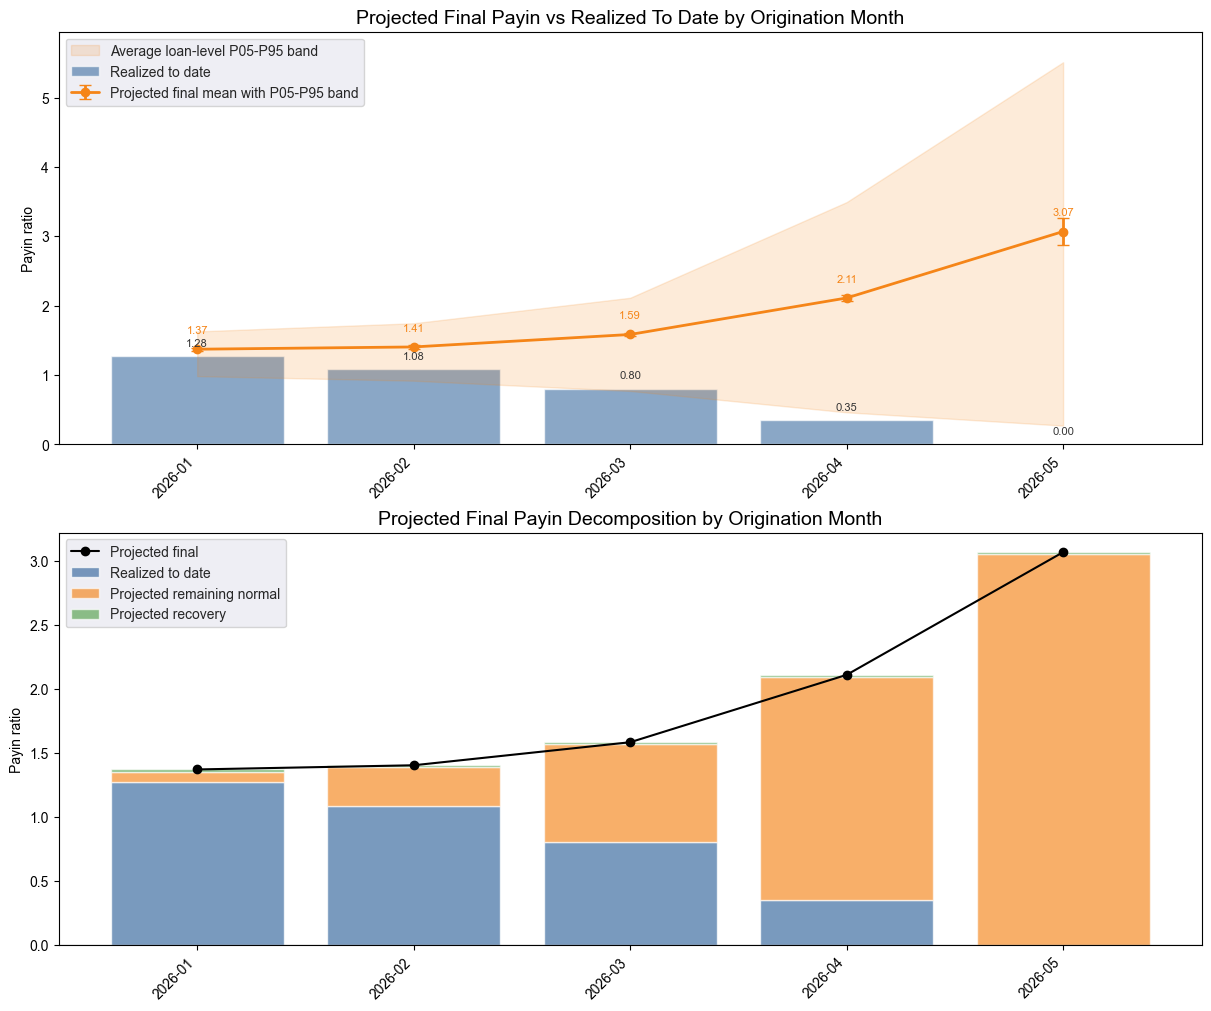

Vintage projection summary (cohort-level P05/P50/P95 band):


,origination_month,loans,originated_amount,realized_payin_to_date,projected_final_payin_mean,projected_final_payin_p05,projected_final_payin_p50,projected_final_payin_p95,cohort_band_width,loan_level_avg_p05,loan_level_avg_p95,loan_level_avg_band_width
0,2026-01,3535,2681300.0,1.276,1.373,1.353,1.374,1.394,0.040,0.985,1.629,0.644
1,2026-02,3634,2798850.0,1.084,1.406,1.383,1.406,1.430,0.047,0.919,1.747,0.828
2,2026-03,4217,3354000.0,0.803,1.585,1.557,1.586,1.611,0.054,0.772,2.114,1.343
3,2026-04,4423,3463350.0,0.351,2.111,2.071,2.113,2.154,0.083,0.464,3.493,3.029
4,2026-05,382,310550.0,0.001,3.069,2.876,3.074,3.265,0.389,0.272,5.508,5.236


Projection decomposition:


,origination_month,loans,originated_amount,realized_payin_to_date,projected_remaining_normal,projected_recovery,projected_final_payin
0,2026-01,3535,2681300.0,1.276,0.075,0.022,1.373
1,2026-02,3634,2798850.0,1.084,0.306,0.016,1.406
2,2026-03,4217,3354000.0,0.803,0.772,0.010,1.585
3,2026-04,4423,3463350.0,0.351,1.747,0.013,2.111
4,2026-05,382,310550.0,0.001,3.053,0.015,3.069


In [8]:
# Visualization: projected final payin vs realized, with cohort-level model bands.
# These charts use the current inference output as-is; they do not change model predictions.
import importlib
import matplotlib.pyplot as plt

import util.projection_visuals as _pvis
importlib.reload(_pvis)

from util.projection_visuals import (
    add_loan_level_band_to_summary,
    build_projection_decomposition,
    build_vintage_projection_summary,
    plot_projection_decomposition,
    plot_vintage_projection,
)

vintage_projection = build_vintage_projection_summary(
    results,
    group_col='origination_month',
    n_sims=1000,
    rng_seed=42,
)
vintage_projection = add_loan_level_band_to_summary(
    vintage_projection,
    results,
    group_col='origination_month',
)
projection_decomposition = build_projection_decomposition(
    results,
    group_col='origination_month',
)

# Exclude tiny malformed/null cohorts from presentation views.
vintage_projection = vintage_projection[vintage_projection['origination_month'].ne('NaT')].copy()
projection_decomposition = projection_decomposition[projection_decomposition['origination_month'].ne('NaT')].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)
plot_vintage_projection(
    vintage_projection,
    title='Projected Final Payin vs Realized To Date by Origination Month',
    ax=axes[0],
)
plot_projection_decomposition(
    projection_decomposition,
    title='Projected Final Payin Decomposition by Origination Month',
    ax=axes[1],
)
plt.show()

print('Vintage projection summary (cohort-level P05/P50/P95 band):')
display(vintage_projection.round(3))
print('Projection decomposition:')
display(projection_decomposition.round(3))

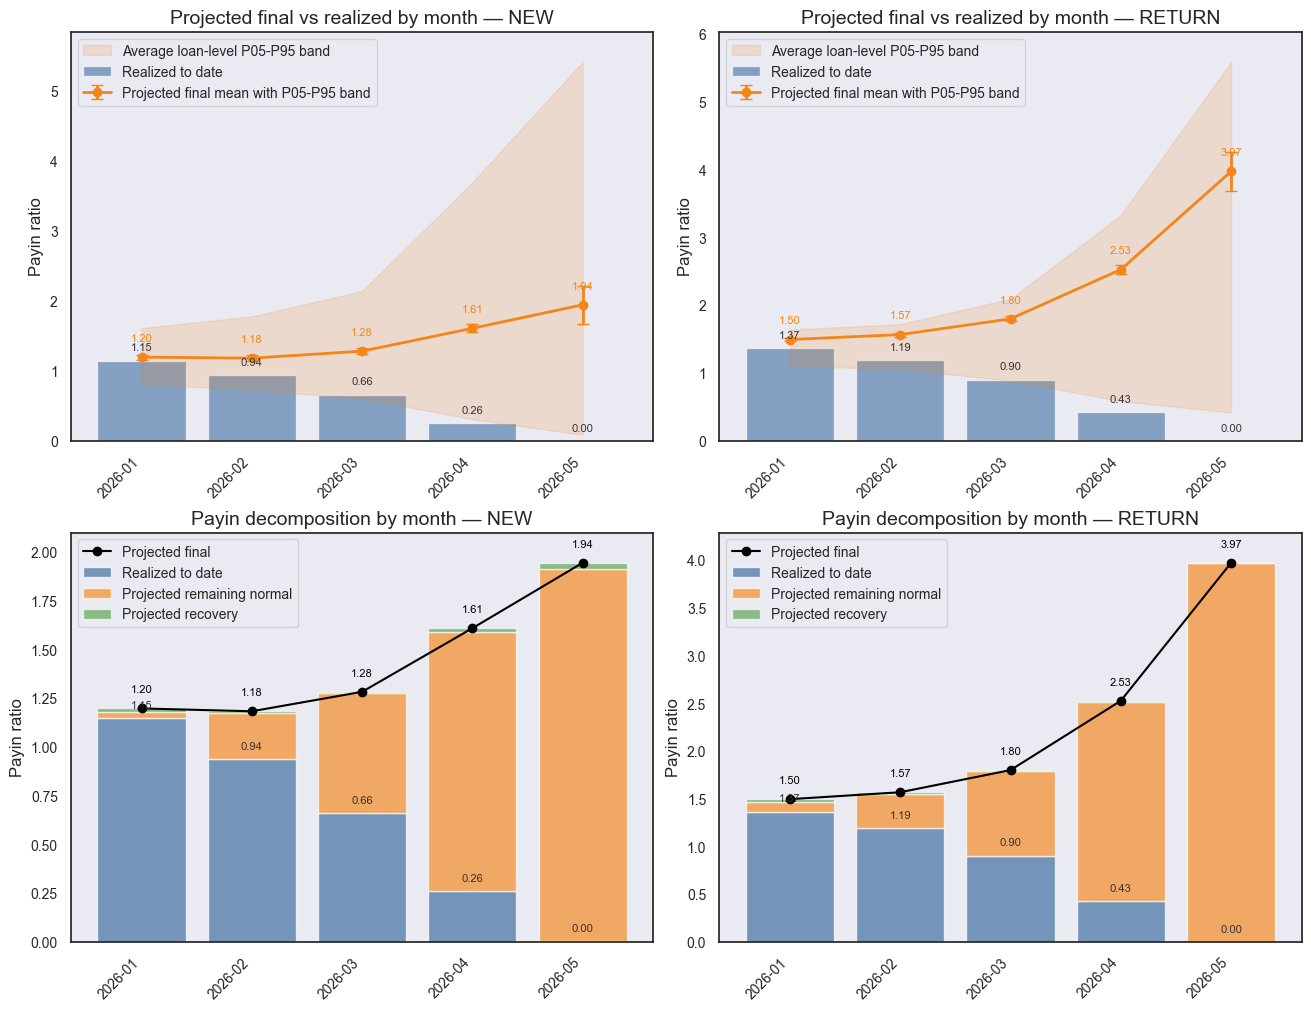

In [9]:
# Visualization by customer type (NEW vs RETURN): same charts as the cell above, faceted by CustType.
# Subsets `results` only; does not re-score. See `util/projection_visuals_by_custtype.py`.
import importlib

import matplotlib.pyplot as plt

import util.projection_visuals as _pvis
import util.projection_visuals_by_custtype as _pvis_ct

importlib.reload(_pvis)
importlib.reload(_pvis_ct)

from util.projection_visuals_by_custtype import plot_inference_faceted_by_custtype

fig = plot_inference_faceted_by_custtype(results, n_sims=1000, rng_seed=42)
plt.show()


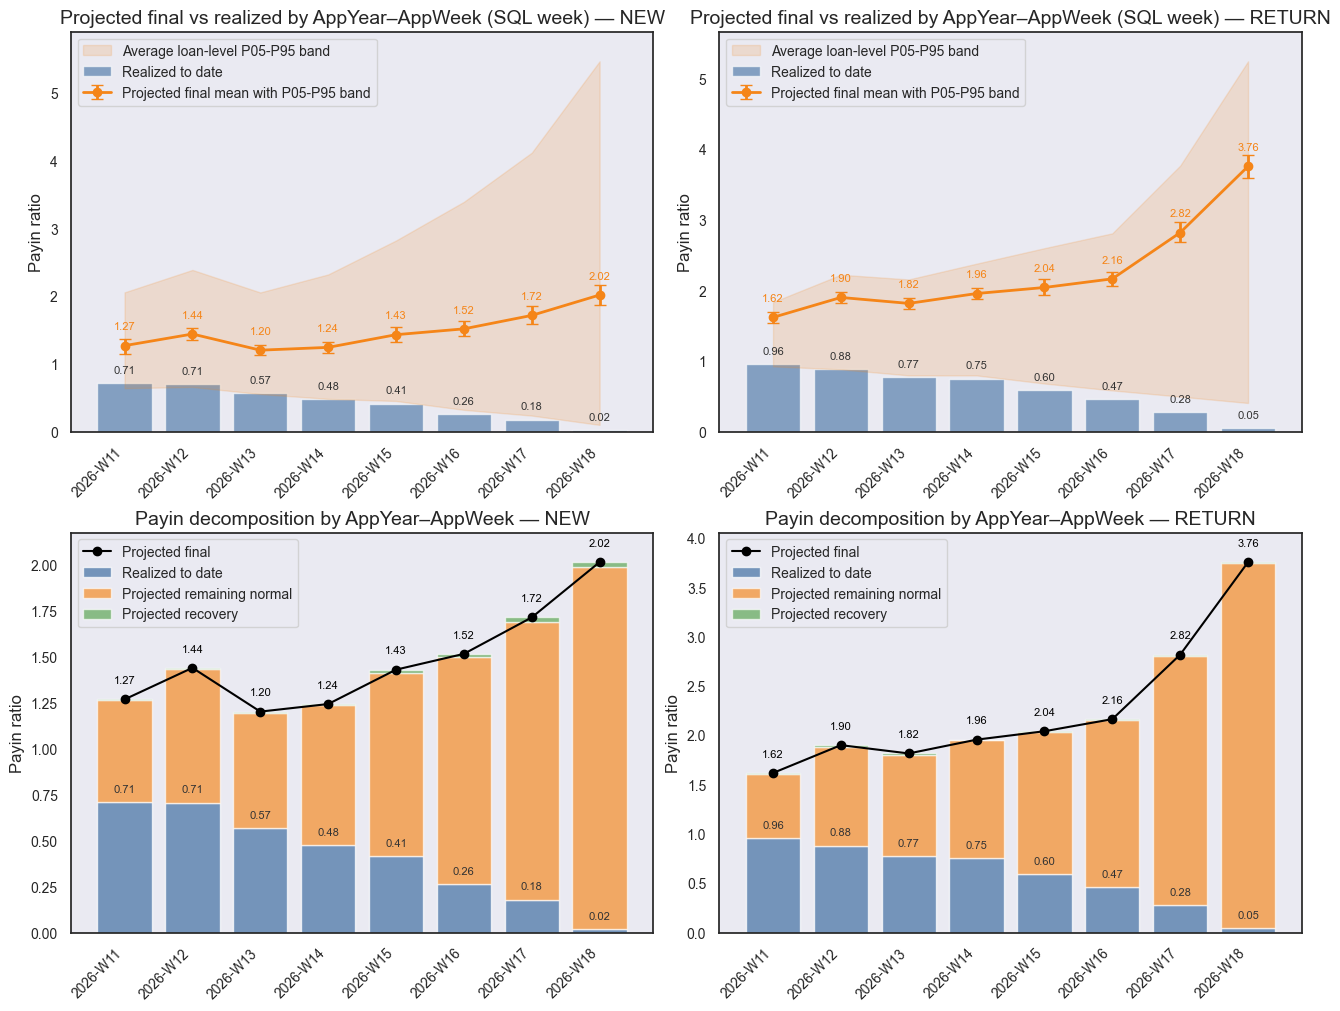

In [10]:
# Recent cohort (origination date window) + AppYear/AppWeek buckets (SQL DATEPART week from extract).
# No extra SQL columns; see `util/projection_visuals_by_custtype.plot_inference_by_custtype_recent_application_weeks`.
import importlib

import matplotlib.pyplot as plt

import util.projection_visuals as _pvis
import util.projection_visuals_by_custtype as _pvis_ct

importlib.reload(_pvis)
importlib.reload(_pvis_ct)

from util.projection_visuals_by_custtype import plot_inference_by_custtype_recent_application_weeks

fig = plot_inference_by_custtype_recent_application_weeks(results, n_weeks=8, n_sims=1000, rng_seed=42)
plt.show()


In [11]:
# QC checks.
qc = results['qc']
print('QC:')
for k, v in qc.items():
    print(f'{k}: {v}')

loan_features = results['loan_features']
seq_features = results['seq_features']
print('\nLoans with no normal payment attempts in SQL extract:', qc['loans_without_payment_attempts'])
print('Observed installment rows as of date:', int(seq_features.get('is_observed', pd.Series(dtype=bool)).sum()) if len(seq_features) else 0)
print('Payin matrix class means:')
display(results['payin_matrix'].mean().round(3))

QC:
as_of_date: 2026-05-06
n_loans: 16194
n_installment_rows: 138559
n_stage_c_rows: 4330
loans_without_payment_attempts: 1816
stage_a_missing_features: []
stage_b_missing_features: []
stage_c_missing_features: []

Loans with no normal payment attempts in SQL extract: 1816
Observed installment rows as of date: 37300
Payin matrix class means:


FPD       0.078
SPD       0.480
TPD       0.710
LatePD    0.879
Clean     2.436
dtype: float64

--- SHAP Review

/Users/starsrain/2025_concord/yieldCurve_augmenting/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/Users/starsrain/2025_concord/yieldCurve_augmenting/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


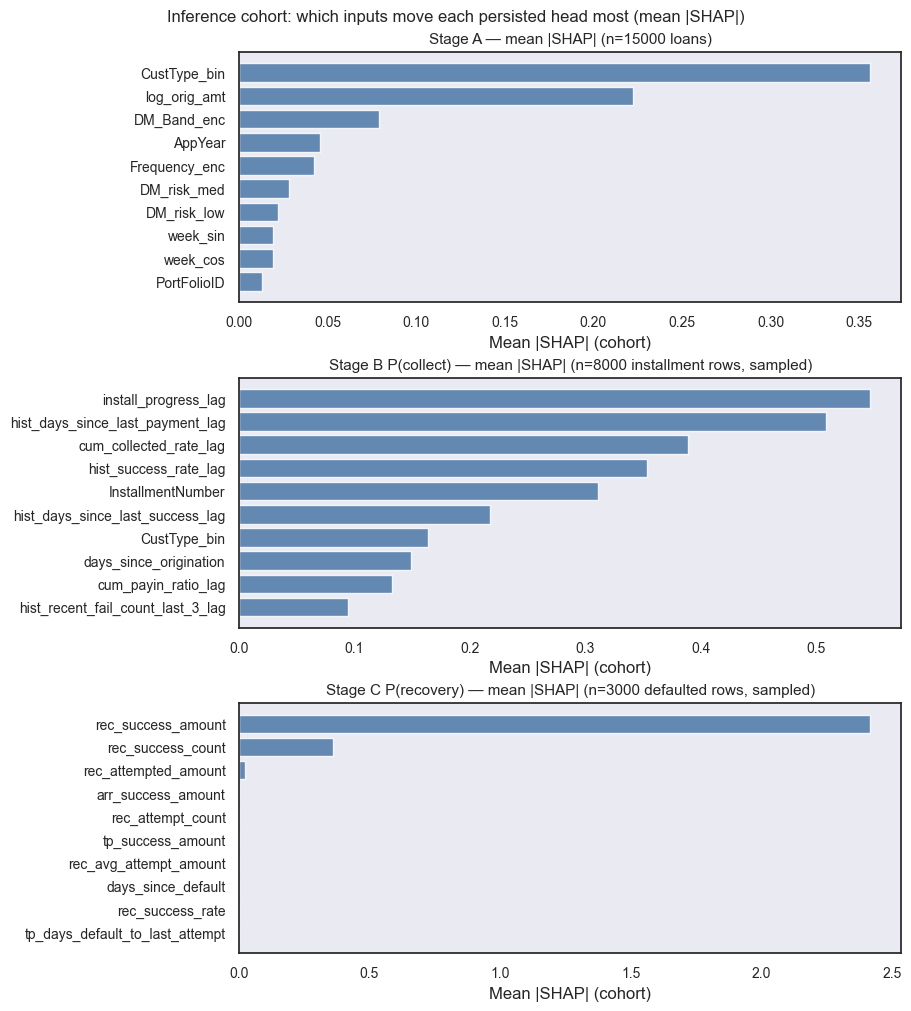

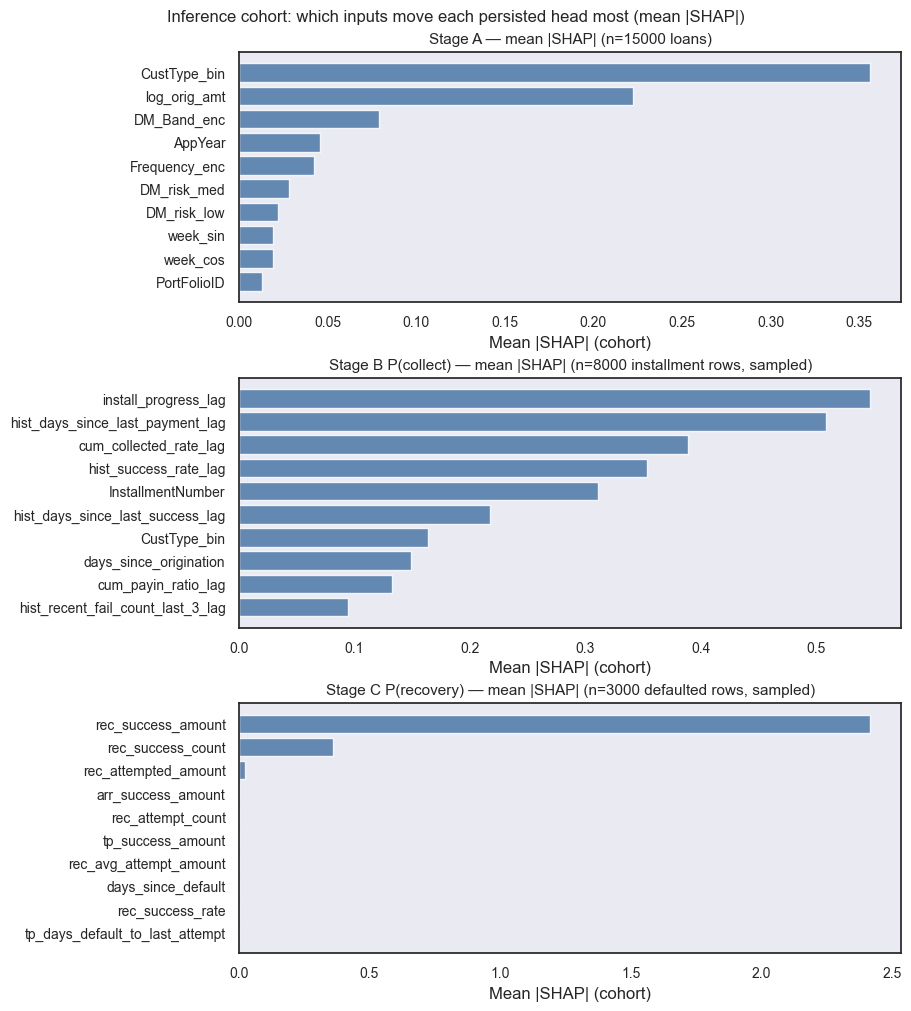

In [12]:
# SHAP overview (inference cohort): mean |SHAP| per feature for each persisted head.
# Same feature matrices as `score_live_projection`: Stage A on all scored loans;
# Stage B classifier on a subsample of installment rows; Stage C classifier on
# defaulted-model rows (subsample). Optional single-loan Stage A drill-down below.
import importlib

import util.projection_shap_inference as _pshap
importlib.reload(_pshap)

from IPython.display import display
from util.projection_shap_inference import plot_inference_shap_overview

# Set to a LoanID string to add a second figure: Stage A SHAP for that loan (Clean class).
DRILL_LOAN_ID = None

fig, fig_drill = plot_inference_shap_overview(
    model_run,
    results,
    top_k=10,
    drill_loan_id=DRILL_LOAN_ID,
    drill_class='Clean',
)
display(fig)
if fig_drill is not None:
    display(fig_drill)
